In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 100)
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error

import sys
sys.path.append("../")
from mlcore.gradient_boost import CustomGradientBoostingClassifier

In [2]:
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy
X, y = datasets.make_classification(n_samples=5_000, n_features=10, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [3]:
custom_gb = CustomGradientBoostingClassifier(n_estimators=20,
                                 loss="log_loss",
                                 max_depth=3,
                                 max_features=None,
                                 min_samples_split=2,
                                 min_samples_leaf=1,
                                 min_impurity_decrease=1e-7,
                                 random_state=42,
                                 verbose=True)
custom_gb.fit(X_train, y_train)
y_pred = custom_gb.predict(X_test)  

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

accu = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accu:.4f}")

Boosting: 100%|██████████| 20/20 [02:49<00:00,  8.45s/it]

MSE: 0.1090
F1 Score: 0.8873
Precision: 0.8882
Recall: 0.8864
Accuracy: 0.8910


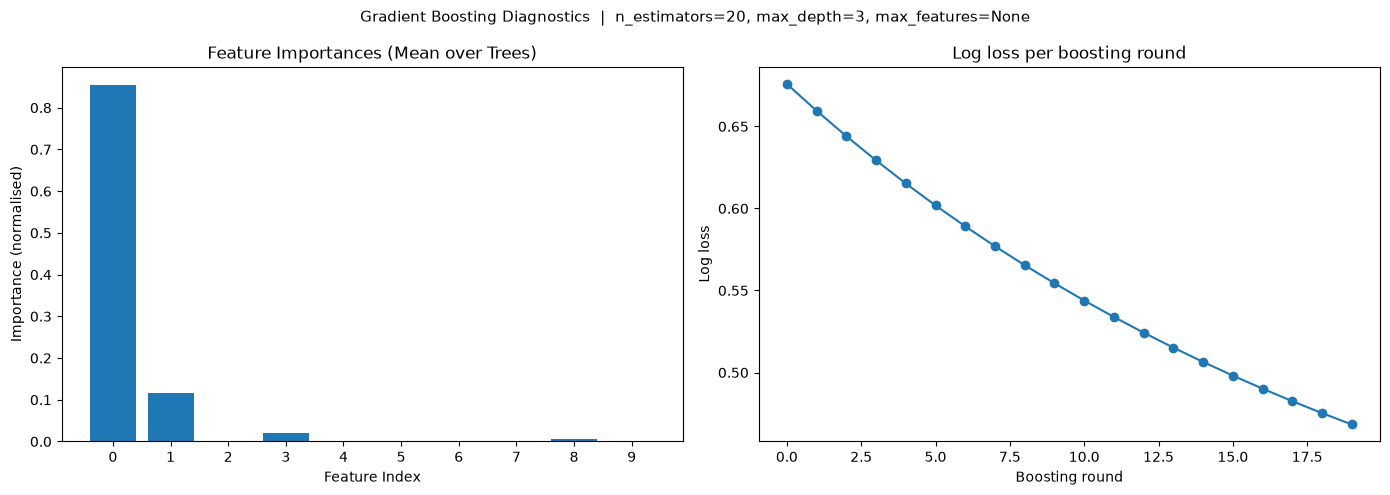

Final training loss: 0.468324


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Feature Importances ---
ax = axes[0]
ax.bar(range(len(custom_gb.feature_importances_)), custom_gb.feature_importances_)
ax.set_title("Feature Importances (Mean over Trees)")
ax.set_xlabel("Feature Index")
ax.set_ylabel("Importance (normalised)")
ax.set_xticks(range(len(custom_gb.feature_importances_)))

# --- Cumulative Cost Reduction per Tree ---
ax = axes[1]
ax.plot(custom_gb.cost_history_, marker="o", linewidth=1.5)
ax.set_title("Log loss per boosting round")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Log loss")

plt.suptitle(
    f"Gradient Boosting Diagnostics  |  n_estimators={custom_gb.n_estimators}, "
    f"max_depth={custom_gb.max_depth}, max_features={custom_gb.max_features}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"Final training loss: {custom_gb.cost_history_[-1]:.6f}")

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

sklearn_gb = GradientBoostingClassifier(n_estimators=20,
                                max_depth=3,
                                max_features=None,
                                min_samples_split=2,
                                min_samples_leaf=1,
                                min_impurity_decrease=1e-7,
                                loss="log_loss",
                                random_state=42)
sklearn_gb.fit(X_train, y_train)
y_pred_sklearn = sklearn_gb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_sklearn)
print(f"MSE: {mse:.4f}")

f1 = f1_score(y_test, y_pred_sklearn)
print(f"F1 Score: {f1:.4f}")

precision = precision_score(y_test, y_pred_sklearn)
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, y_pred_sklearn)
print(f"Recall: {recall:.4f}")

accu = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuracy: {accu:.4f}")

MSE: 0.0840
F1 Score: 0.9132
Precision: 0.9132
Recall: 0.9132
Accuracy: 0.9160
